<a href="https://colab.research.google.com/github/sarim711/parkinsons-ML-xai-art/blob/main/preprocessing_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/parkinsons

/content/drive/MyDrive/parkinsons


In [3]:
%ls


load_data.ipynb  main.ipynb  parkinsons_updrs.data


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [35]:
df = pd.read_csv("parkinsons_updrs.data")

In [36]:
df.head(5)

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


In [37]:
df["total_updrs_class"] = pd.qcut(df["total_UPDRS"], q= 3, labels = [0,1,2])

In [38]:
df.head(5)

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE,total_updrs_class
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006,2
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810,2
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014,2
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277,2
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361,2


In [39]:
patient_ = df[df["subject#"] == 2]

In [40]:
patient_.head(35)

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE,total_updrs_class
149,2,58,0,3.866,11.078,14.039,0.00600,0.000048,0.00302,0.00294,...,0.02058,0.02464,0.02778,0.06175,0.019901,20.632,0.54100,0.75905,0.19288,0
150,2,58,0,10.815,11.218,14.109,0.00810,0.000064,0.00418,0.00457,...,0.02715,0.02974,0.03218,0.08144,0.026285,18.254,0.48799,0.76679,0.22277,0
151,2,58,0,17.772,11.359,14.180,0.00804,0.000062,0.00385,0.00435,...,0.02037,0.02216,0.02621,0.06111,0.024588,18.844,0.49372,0.78209,0.29585,0
152,2,58,0,24.808,11.501,14.251,0.00680,0.000049,0.00350,0.00319,...,0.02733,0.03268,0.03511,0.08198,0.034226,18.272,0.54635,0.73637,0.21570,0
153,2,58,0,31.815,11.643,14.321,0.00375,0.000028,0.00201,0.00209,...,0.01684,0.01845,0.02269,0.05052,0.011958,20.456,0.44009,0.73302,0.18964,0
154,2,58,0,38.713,11.782,14.391,0.00685,0.000050,0.00302,0.00399,...,0.01847,0.02205,0.02954,0.05542,0.036966,19.645,0.57472,0.73373,0.25354,0
155,2,58,0,45.800,11.925,14.463,0.00859,0.000066,0.00444,0.00511,...,0.02472,0.02815,0.03315,0.07417,0.034790,17.162,0.62855,0.74011,0.33120,0
156,2,58,0,54.767,12.106,14.553,0.00402,0.000031,0.00208,0.00237,...,0.03011,0.03574,0.04501,0.09033,0.013458,19.732,0.49181,0.70492,0.19820,0
157,2,58,0,59.800,12.208,14.604,0.00783,0.000055,0.00448,0.00398,...,0.04965,0.05207,0.05804,0.14894,0.030341,16.972,0.60460,0.71757,0.26869,0
158,2,58,0,68.728,12.388,14.694,0.00687,0.000055,0.00340,0.00345,...,0.02444,0.02460,0.03121,0.07333,0.036049,15.775,0.61152,0.74542,0.26677,0


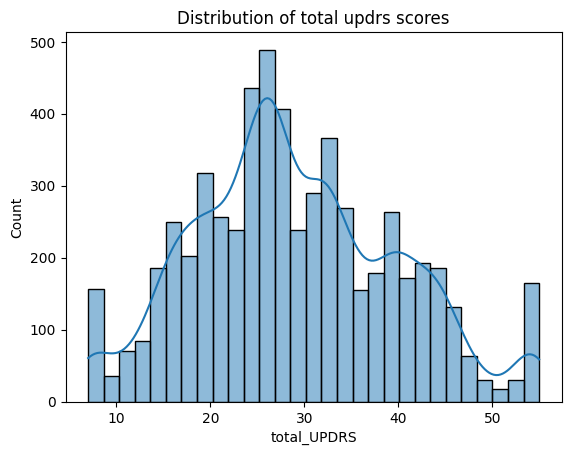

In [41]:
sns.histplot(df["total_UPDRS"], kde = True)
plt.title("Distribution of total updrs scores")
plt.show()

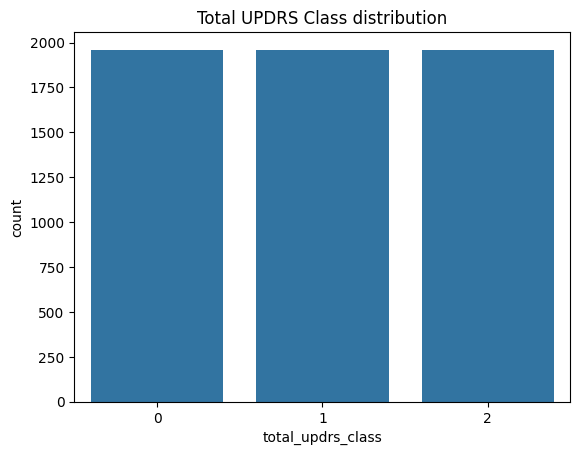

In [42]:
sns.countplot(x = df["total_updrs_class"])
plt.title("Total UPDRS Class distribution")
plt.show()

In [43]:
X = df.drop(["motor_UPDRS", "total_UPDRS", "total_updrs_class"], axis = 1, inplace = False)

In [45]:
X.head(5)

,subject#,age,sex,test_time,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,Shimmer,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,0.00662,0.000034,0.00401,0.00317,0.01204,0.02565,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,0.00300,0.000017,0.00132,0.00150,0.00395,0.02024,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,0.00481,0.000025,0.00205,0.00208,0.00616,0.01675,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,0.00528,0.000027,0.00191,0.00264,0.00573,0.02309,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,0.00335,0.000020,0.00093,0.00130,0.00278,0.01703,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


In [177]:
y = df["total_updrs_class"]

In [178]:
groups = df["subject#"].to_numpy()

In [179]:
test_size = 10/42

In [180]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=5,
    test_size=test_size,
    random_state=44
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)


In [181]:
X_train = X.iloc[train_idx]
X_test  = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]


In [182]:
train_patients = set(groups[train_idx])
test_patients  = set(groups[test_idx])

print("Train patients:", len(train_patients))
print("Test patients :", len(test_patients))
print("Overlap:", train_patients & test_patients)


Train patients: 32
Test patients : 10
Overlap: set()


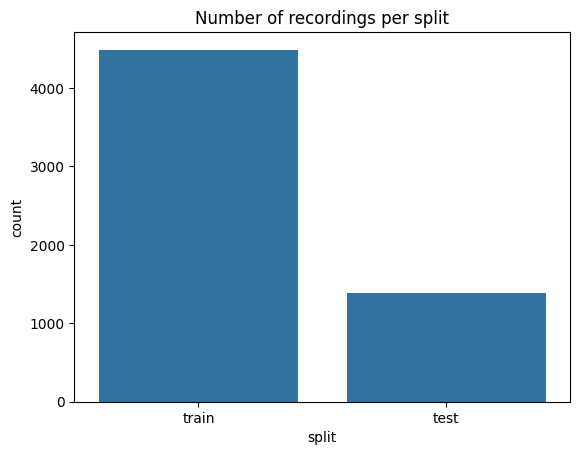

In [183]:
import seaborn as sns
import matplotlib.pyplot as plt


split_df = pd.DataFrame({
    'patient_id': groups,
    'split': ['train' if i in train_idx else 'test' for i in range(len(groups))]
})

sns.countplot(x='split', data=split_df)
plt.title("Number of recordings per split")
plt.show()


In [184]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.005,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=44
)

model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.005, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [193]:
from sklearn.metrics import mean_absolute_error
y_preds = model.predict(X_test)
y_preds[10:50]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [192]:
y_test[10:50]

,total_updrs_class
741,2
742,2
743,2
744,2
745,2
746,2
747,2
748,2
749,2
750,2


In [189]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_preds)

In [190]:
print(acc)

0.3708513708513709
